# FairLinear

Fair linear regression via gradient descent with CKA penalty (100 epochs).

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np

from fairkl.models import FairLinear
from fairkl.metrics.cka import cka_rbf
from _style import SCATTER_KW, style_ax

## Synthetic Data

`X = [x, q]` with `y = x + 3*q + noise`.

In [2]:
rng = np.random.default_rng(0)
n = 200
x_feat = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x_feat, q]).astype("float32")
y = (x_feat.ravel() + 3.0 * q.ravel() + 0.2 * rng.standard_normal(n)).astype("float32")

print(f"Corr(y, q) = {np.corrcoef(y, q.ravel())[0, 1]:.3f}")

Corr(y, q) = 0.950


## Training

In [3]:
mus = [0.0, 0.5, 2.0, 10.0]
results = {}

# Train mu=0 first, then warm-start higher mus from its weights.
base = FairLinear(lam=1e-3, mu=0.0, sigma_q=1.0)
base.fit(X, y, q=q, epochs=100, lr=0.05)
w_init = np.array(base._w.value)
b_init = np.array(base._b.value)

for mu in mus:
    if mu == 0:
        model = base
    else:
        model = FairLinear(lam=1e-3, mu=mu, sigma_q=1.0)
        model.fit(X, y, q=q, epochs=1, lr=0.05)  # build
        model._w.assign(w_init)
        model._b.assign(b_init)
        model.fit(X, y, q=q, epochs=100, lr=0.05)
    yh = np.array(model.predict(X)).ravel()
    mse = float(np.mean((yh - y) ** 2))
    cka_val = float(cka_rbf(yh.reshape(-1, 1), q))
    results[mu] = {"mse": mse, "cka": cka_val, "yh": yh}
    print(f"mu={mu:5.1f}  MSE={mse:.3f}  CKA={cka_val:.3f}")

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


mu=  0.0  MSE=0.084  CKA=0.570


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

...

mu=  2.0  MSE=0.149  CKA=0.457


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


mu= 10.0  MSE=1.255  CKA=0.241


## Predictions vs Sensitive Attribute

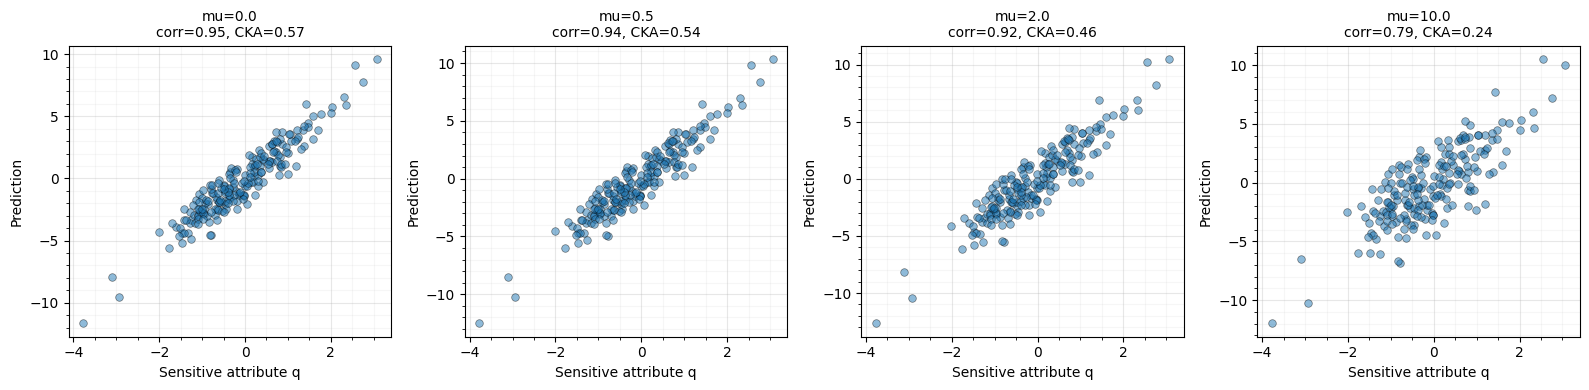

In [4]:
fig, axes = plt.subplots(1, len(mus), figsize=(4 * len(mus), 4))
for ax, mu in zip(axes, mus):
    yh = results[mu]["yh"]
    corr = np.corrcoef(yh, q.ravel())[0, 1]
    ax.scatter(q.ravel(), yh, c="C0", **SCATTER_KW)
    ax.set_xlabel("Sensitive attribute q")
    ax.set_ylabel("Prediction")
    ax.set_title(f"mu={mu}\ncorr={corr:.2f}, CKA={results[mu]['cka']:.2f}", fontsize=10)
    style_ax(ax)
plt.tight_layout()
plt.show()

## Pareto Frontier

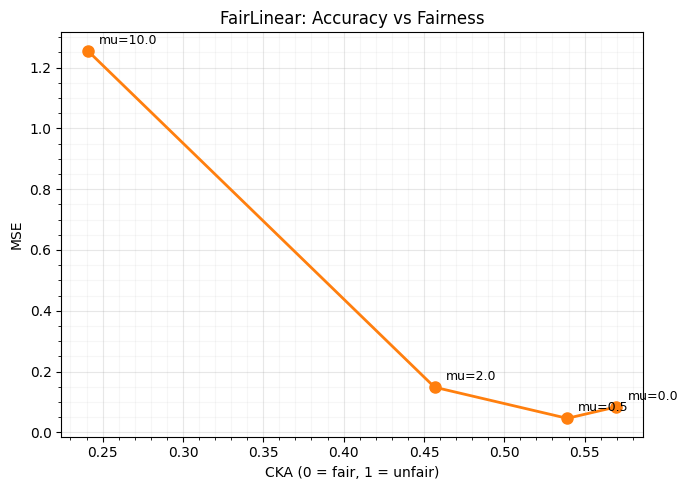

In [5]:
mses = [results[mu]["mse"] for mu in mus]
ckas = [results[mu]["cka"] for mu in mus]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ckas, mses, "o-", color="C1", lw=2, markersize=8)
for i, mu in enumerate(mus):
    ax.annotate(
        f"mu={mu}",
        (ckas[i], mses[i]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
    )
ax.set_xlabel("CKA (0 = fair, 1 = unfair)")
ax.set_ylabel("MSE")
ax.set_title("FairLinear: Accuracy vs Fairness")
style_ax(ax)
plt.tight_layout()
plt.show()